In [12]:
# Import required libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

In [32]:
#Load the dataset
trans_df=pd.read_csv('../data/transactions_cleaned.csv')
trans_df.head()

,trans_id,trans_datetime,cc_num,merchant,category,amt,firstname,lastname,gender,street,...,trans_day,trans_hour,time_period,fullname,high_amount_risk,night_risk,txn_per_card,freq_risk,location_risk,risk_score
0,1,2020-06-21 12:14:00,2.291160e+15,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,Sunday,12,Day,Jeff Elliott,0,0,640,1,0,1
1,2,2020-06-21 12:14:00,3.573030e+15,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,Sunday,12,Day,Joanne Williams,0,0,837,1,0,1
2,3,2020-06-21 12:14:00,3.598220e+15,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,Sunday,12,Day,Ashley Lopez,0,0,1073,1,0,1
3,4,2020-06-21 12:15:00,3.591920e+15,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,Sunday,12,Day,Brian Williams,0,0,663,1,0,1
4,5,2020-06-21 12:15:00,3.526830e+15,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,Sunday,12,Day,Nathan Massey,0,0,891,1,0,1


In [14]:
#Define features (X) and target (y)

x=trans_df[['high_amount_risk','night_risk','freq_risk','location_risk','risk_score']]
y=trans_df['is_fraud']

In [15]:
#Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [30]:
# OLD MODEL (without balancing)
old_model = LogisticRegression()

old_model.fit(X_train, y_train)

y_pred_old = old_model.predict(X_test)

print("OLD MODEL RESULTS")
print(confusion_matrix(y_test, y_pred_old))
print(classification_report(y_test, y_pred_old))

OLD MODEL RESULTS
[[110718      0]
 [   401     25]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    110718
           1       1.00      0.06      0.11       426

    accuracy                           1.00    111144
   macro avg       1.00      0.53      0.55    111144
weighted avg       1.00      1.00      0.99    111144



In [31]:
# NEW MODEL (with class_weight)
new_model = LogisticRegression(class_weight='balanced')

new_model.fit(X_train, y_train)

y_pred_new = new_model.predict(X_test)

print("NEW MODEL RESULTS")
print(confusion_matrix(y_test, y_pred_new))
print(classification_report(y_test, y_pred_new))

NEW MODEL RESULTS
[[105986   4732]
 [    83    343]]
              precision    recall  f1-score   support

           0       1.00      0.96      0.98    110718
           1       0.07      0.81      0.12       426

    accuracy                           0.96    111144
   macro avg       0.53      0.88      0.55    111144
weighted avg       1.00      0.96      0.97    111144



In [20]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9566778233642842


In [25]:
X = trans_df[['high_amount_risk','night_risk','freq_risk','location_risk','risk_score']]

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_[0]
})

feature_importance = feature_importance.sort_values(by="coefficient", ascending=False)

feature_importance

,feature,coefficient
0,high_amount_risk,4.781311
1,night_risk,1.351778
3,location_risk,0.000000
4,risk_score,-0.665918
2,freq_risk,-6.799007


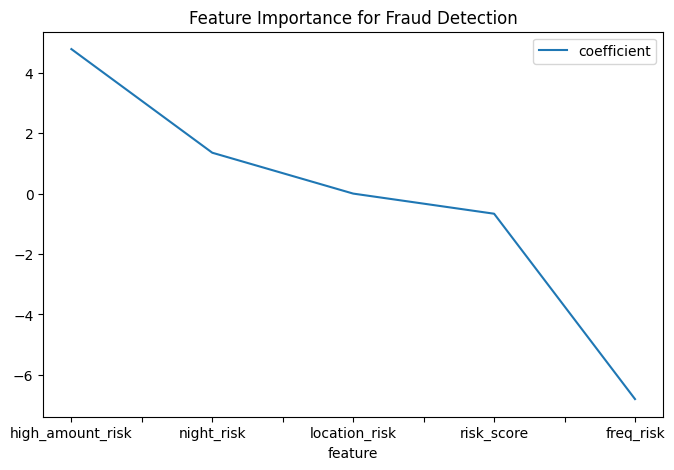

In [29]:
import matplotlib.pyplot as plt

feature_importance.plot(
    x="feature",
    y="coefficient",
    kind="line",
    title="Feature Importance for Fraud Detection",
    figsize=(8,5)
)

plt.show()

### Model Comparison

The baseline model achieved high accuracy but failed to detect most fraudulent transactions due to class imbalance.

The balanced logistic regression model improved recall significantly, detecting more fraud cases, although it increased false positives.

For fraud detection, recall is more important than accuracy, making the balanced model more suitable.